In [82]:
import pandas as pd
import numpy as np
import gzip
import os
import re
import nltk
import tensorflow as tf, keras
import matplotlib.pyplot as plt
from datasets import load_dataset
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Concatenate
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [36]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rutvikdhopate/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/rutvikdhopate/nltk_data...


True

In [18]:
dataset = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_review_Appliances",
    split="full",
    # streaming=True,  # Enables streaming mode (no large file download)
    trust_remote_code=True
)

Appliances.jsonl:   0%|          | 0.00/929M [00:00<?, ?B/s]

Generating full split: 0 examples [00:00, ? examples/s]

In [25]:
# Select only essential columns
essential_columns = ["user_id", "asin", "text", "rating", "timestamp"]
filtered_dataset = dataset.remove_columns([col for col in dataset.column_names if col not in essential_columns])

In [26]:
# Collect a sample of 100k 
sample_data = []
for i, sample in enumerate(filtered_dataset):
    if i >= 100000:
        break
    sample_data.append(sample)

# Convert to Pandas DataFrame
df = pd.DataFrame(sample_data)

In [27]:
df.to_csv("appliances_reviews.csv", header=True, index=False, encoding='utf-8')

In [32]:
# Data Preprocessing

# According to DeepCoNN, user reviews and item reviews are expected to be inputs for 2 different NNs

user_reviews = df.groupby("user_id")["text"].apply(lambda x: " ".join(x)).reset_index()
user_reviews.rename(columns={"text": "user_review"}, inplace=True)

item_reviews = df.groupby("asin")["text"].apply(lambda x: " ".join(x)).reset_index()
item_reviews.rename(columns={"text": "item_review"}, inplace=True)

df = df.merge(user_reviews, on="user_id", how="left")
df = df.merge(item_reviews, on="asin", how="left")

In [35]:
df.head()

,rating,text,asin,user_id,timestamp,user_review,item_review
0,5.0,work great. use a new one every month,B01N0TQ0OH,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1519317108692,work great. use a new one every month,work great. use a new one every month Have onl...
1,5.0,Little on the thin side,B07DD2DMXB,AHWWLSPCJMALVHDDVSUGICL6RUCA,1664746863446,Little on the thin side,Little on the thin side These are a lot thinne...
2,5.0,"Quick delivery, fixed the issue!",B082W3Z9YK,AHZIJGKEWRTAEOZ673G5B3SNXEGQ,1607225435363,"Quick delivery, fixed the issue!","Quick delivery, fixed the issue! LER5620KQ1 Wh..."
3,5.0,I wasn't sure whether these were worth it or n...,B078W2BJY8,AFGUPTDFAWOHHL4LZDV27ERDNOYQ,1534104184306,I wasn't sure whether these were worth it or n...,I wasn't sure whether these were worth it or n...
4,5.0,Easy to install got the product expected to re...,B08C9LPCQV,AELFJFAXQERUSMTXJQ6SYFFRDWMA,1620176603754,Easy to install got the product expected to re...,Easy to install got the product expected to re...


In [37]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def clean_text(text):
    if isinstance(text, str):  # Check if text is valid
        text = text.lower()  # Convert to lowercase
        text = re.sub(r"[^a-z0-9]", " ", text)  # Remove special characters
        text = " ".join([word for word in text.split() if word not in stop_words])  # Remove stopwords
        text = " ".join([lemmatizer.lemmatize(word) for word in text.split()])  # Lemmatization
        return text
    return ""


df["user_review"] = df["user_review"].apply(clean_text)
df["item_review"] = df["item_review"].apply(clean_text)

# Save cleaned dataset
df.to_csv("amazon_appliances_cleaned.csv", index=False)

In [39]:
df.head()

,rating,text,asin,user_id,timestamp,user_review,item_review
0,5.0,work great. use a new one every month,B01N0TQ0OH,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1519317108692,work great use new one every month,work great use new one every month used 2 far ...
1,5.0,Little on the thin side,B07DD2DMXB,AHWWLSPCJMALVHDDVSUGICL6RUCA,1664746863446,little thin side,little thin side lot thinner original filter g...
2,5.0,"Quick delivery, fixed the issue!",B082W3Z9YK,AHZIJGKEWRTAEOZ673G5B3SNXEGQ,1607225435363,quick delivery fixed issue,quick delivery fixed issue ler5620kq1 whirlpoo...
3,5.0,I wasn't sure whether these were worth it or n...,B078W2BJY8,AFGUPTDFAWOHHL4LZDV27ERDNOYQ,1534104184306,sure whether worth given cost compared origina...,sure whether worth given cost compared origina...
4,5.0,Easy to install got the product expected to re...,B08C9LPCQV,AELFJFAXQERUSMTXJQ6SYFFRDWMA,1620176603754,easy install got product expected receive,easy install got product expected receive


In [40]:
# Convert user id and item id to numerical indices as NNs don't support alphanumeric ASINs

user2idx = {user: idx for idx, user in enumerate(df["user_id"].unique())}
item2idx = {item: idx for idx, item in enumerate(df["asin"].unique())}

df["user_id"] = df["user_id"].map(user2idx)
df["asin"] = df["asin"].map(item2idx)

df.to_csv("amazon_appliances_final.csv", index=False)

In [45]:
# Set parameters
MAX_VOCAB_SIZE = 50000  # Maximum number of words in the vocabulary
MAX_SEQUENCE_LENGTH = 300  # Maximum number of words per review

# Initialize Tokenizer
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df["user_review"].tolist() + df["item_review"].tolist())

# Convert text to sequences
df["user_review_seq"] = tokenizer.texts_to_sequences(df["user_review"])
df["item_review_seq"] = tokenizer.texts_to_sequences(df["item_review"])

# Pad sequences
df["user_review_seq"] = list(pad_sequences(df["user_review_seq"], maxlen=MAX_SEQUENCE_LENGTH, padding="post"))
df["item_review_seq"] = list(pad_sequences(df["item_review_seq"], maxlen=MAX_SEQUENCE_LENGTH, padding="post"))

# Save tokenized dataset
df.to_csv("amazon_appliances_tokenized.csv", index=False)

Text Tokenization & Padding Completed ✅


In [46]:
# Model Parameters
EMBEDDING_DIM = 300  # Word embedding dimension
FILTERS = 100  # Number of CNN filters
KERNEL_SIZE = 3  # Convolution window size
DENSE_UNITS = 128  # Fully connected layer units

def cnn_block(input_layer):
    x = Embedding(input_dim = MAX_VOCAB_SIZE, output_dim = EMBEDDING_DIM, input_length = MAX_SEQUENCE_LENGTH)(input_layer)
    x = Conv1D(filters=FILTERS, kernel_size = KERNEL_SIZE, activation="relu")(x)
    x = GlobalMaxPooling1D()(x)
    x = Dense(DENSE_UNITS, activation="relu")(x)
    return x

user_input = Input(shape=(MAX_SEQUENCE_LENGTH, ), name="user_input")
user_output = cnn_block(user_input)

item_input = Input(shape=(MAX_SEQUENCE_LENGTH, ), name="item_input")
item_output = cnn_block(item_input)

merged = Concatenate()([user_output, item_output])
merged = Dense(DENSE_UNITS, activation="relu")(merged)
rating_prediction = Dense(1, activation="linear")(merged)

deepconn_model = Model(inputs=[user_input, item_input], outputs=rating_prediction)

deepconn_model.compile(optimizer="adam", loss="mse", metrics=["mae"])

deepconn_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 user_input (InputLayer)     [(None, 300)]                0         []                            
                                                                                                  
 item_input (InputLayer)     [(None, 300)]                0         []                            
                                                                                                  
 embedding (Embedding)       (None, 300, 300)             1500000   ['user_input[0][0]']          
                                                          0                                       
                                                                                                  
 embedding_1 (Embedding)     (None, 300, 300)             1500000   ['item_input[0][0]']      

In [49]:
# Train the model

# df["user_review_seq"] = df["user_review_seq"].apply(lambda x: np.array(eval(x)))
# df["item_review_seq"] = df["item_review_seq"].apply(lambda x: np.array(eval(x)))

X_user = np.array(df["user_review_seq"].tolist()) 
X_item = np.array(df["item_review_seq"].tolist()) 
y = np.array(df["rating"])  

In [52]:
# Split the Data

X_user_train, X_user_test, X_item_train, X_item_test, y_train, y_test = train_test_split(
    X_user, X_item, y, test_size=0.2, random_state=42
)

In [54]:
history = deepconn_model.fit(
    [X_user_train, X_item_train], y_train,
    validation_data = ([X_user_test, X_item_test], y_test),
    epochs=5,
    batch_size=128,
    verbose=1
)

deepconn_model.save("deepconn_amazon_appliances.h5")

Epoch 1/5
625/625 [==============================] - 136s 217ms/step - loss: 1.3164 - mae: 0.7817 - val_loss: 0.8907 - val_mae: 0.6355
Epoch 2/5
625/625 [==============================] - 521s 834ms/step - loss: 0.7412 - mae: 0.5757 - val_loss: 0.9015 - val_mae: 0.6251
Epoch 3/5
625/625 [==============================] - 139s 223ms/step - loss: 0.5591 - mae: 0.4853 - val_loss: 0.9433 - val_mae: 0.6891
Epoch 4/5
625/625 [==============================] - 167s 267ms/step - loss: 0.4461 - mae: 0.4277 - val_loss: 1.0182 - val_mae: 0.6234
Epoch 5/5
625/625 [==============================] - 172s 274ms/step - loss: 0.3713 - mae: 0.3847 - val_loss: 1.0379 - val_mae: 0.6064


/Users/rutvikdhopate/Library/Python/3.9/lib/python/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [62]:
def round_to_nearest_half(pred):
    return round(pred * 2)/2

In [91]:
# Model Evaluation

y_pred = deepconn_model.predict([X_user_test, X_item_test])
y_pred = np.array(list(map(lambda x: round_to_nearest_half(x), y_pred[:, 0])))

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)


625/625 [==============================] - 8s 13ms/step


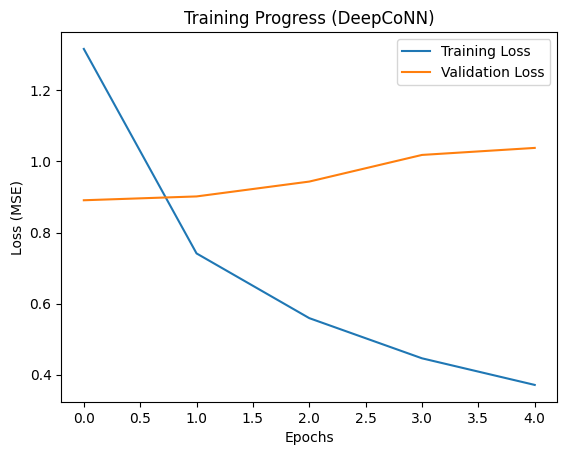

In [83]:
# Plot the Loss Curve

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Training Progress (DeepCoNN)")
plt.legend()
plt.show()